# PointNet++ Workshop: 3D Point Cloud Deep Learning

**Educational Colab Notebook for Survey Engineering Students**

This workshop teaches point cloud processing and PointNet++ deep learning through hands-on experimentation with the ModelNet10 dataset.


## Learning Objectives

After completing this workshop, you will:

1. **Understand** point cloud data structure and characteristics
2. **Visualize** how data preprocessing affects point clouds
3. **Explain** PointNet++ hierarchical abstraction mechanism
4. **Interpret** what features neural networks learn from 3D geometry
5. **Analyze** model predictions and identify failure cases
6. **Connect** deep learning concepts to survey engineering applications
7. **Have** a working notebook to experiment with your own 3D data


## Section 1: Setup & Introduction

### What is PointNet++?

PointNet++ is a deep learning architecture designed specifically for processing unordered sets of 3D points (point clouds). Unlike traditional 2D images, point clouds are:

- **Unordered**: No inherent ordering of points
- **Sparse**: Not every voxel contains data
- **Hierarchical**: Points can be grouped at multiple scales

### Why it matters for survey engineering:

- **Building classification** from BIM point clouds
- **Terrain feature recognition** (vegetation, buildings, ground)
- **Urban furniture detection** in mobile mapping data
- **Quality control** for construction monitoring


PyTorch version: 2.8.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 3070
GPU Memory: 8.59 GB


In [ ]:
# Install PyTorch Geometric (if needed in Colab)
# !pip install torch==2.8.0 --index-url https://download.pytorch.org/whl/cu128
# !pip install torch-geometric torch-scatter torch-sparse torch-cluster -f https://data.pyg.org/whl/torch-2.8.0+cu118.html
# !pip install plotly seaborn scikit-learn tqdm ipywidgets

In [ ]:
# Check GPU availability
import torch
import torch_geometric

print(f"PyTorch version: {torch.__version__}")
print(f"Torch Geometric version: {torch_geometric.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(
        f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB"
    )

In [3]:
"""
Workshop utility functions for PointNet++ visualization and analysis.

This module provides helper functions for:
- Interactive 3D point cloud visualization
- Feature visualization and dimensionality reduction
- Prediction analysis and confusion matrices
"""

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import torch


def plot_point_cloud_plotly(pos, colors=None, title="Point Cloud", size=2):
    """
    Create an interactive 3D scatter plot using Plotly.

    Args:
        pos: (N, 3) tensor or array of 3D coordinates
        colors: (N,) array of color values, or None to use height (z-coordinate)
        title: String title for the plot
        size: Point size for visualization

    Returns:
        plotly figure object
    """
    pos = pos.cpu().numpy() if torch.is_tensor(pos) else pos

    if colors is None:
        # Use z-coordinate for color (depth perception)
        colors = pos[:, 2]
    else:
        colors = colors.cpu().numpy() if torch.is_tensor(colors) else colors

    fig = go.Figure(
        data=[
            go.Scatter3d(
                x=pos[:, 0],
                y=pos[:, 1],
                z=pos[:, 2],
                mode="markers",
                marker=dict(
                    size=size,
                    color=colors,
                    colorscale="Viridis",
                    showscale=True,
                    colorbar=dict(title="Height (Z)")
                    if colors is None or len(colors.shape) == 1
                    else None,
                ),
                text=np.arange(len(pos)),
                hoverinfo="text",
            )
        ]
    )

    fig.update_layout(
        title=title,
        scene=dict(
            xaxis_title="X", yaxis_title="Y", zaxis_title="Z", aspectmode="data"
        ),
        width=800,
        height=800,
        hovermode="closest",
    )

    return fig


def plot_point_cloud_matplotlib(
    pos, colors=None, ax=None, title="", cmap="viridis"
):
    """
    Create a static 3D scatter plot using Matplotlib.

    Args:
        pos: (N, 3) tensor or array of 3D coordinates
        colors: (N,) array of color values, or None to use height
        ax: matplotlib 3D axes object, or None to create new figure
        title: String title for the plot
        cmap: colormap name

    Returns:
        matplotlib axes object
    """
    pos = pos.cpu().numpy() if torch.is_tensor(pos) else pos

    if ax is None:
        fig = plt.figure(figsize=(8, 8))
        ax = fig.add_subplot(111, projection="3d")

    if colors is None:
        colors = pos[:, 2]
    else:
        colors = colors.cpu().numpy() if torch.is_tensor(colors) else colors

    scatter = ax.scatter(
        pos[:, 0], pos[:, 1], pos[:, 2], c=colors, cmap=cmap, s=10
    )

    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    ax.set_title(title)
    plt.colorbar(scatter, ax=ax, pad=0.1)

    return ax


def plot_transformation_comparison(
    original, transformed, titles=("Original", "Transformed")
):
    """
    Create side-by-side 3D visualization of before/after transformation.

    Args:
        original: (N, 3) tensor or array of original coordinates
        transformed: (M, 3) tensor or array of transformed coordinates
        titles: Tuple of (original_title, transformed_title)

    Returns:
        matplotlib figure with two 3D subplots
    """
    fig = plt.figure(figsize=(14, 6))

    # Original
    ax1 = fig.add_subplot(121, projection="3d")
    plot_point_cloud_matplotlib(original, ax=ax1, title=titles[0])

    # Transformed
    ax2 = fig.add_subplot(122, projection="3d")
    plot_point_cloud_matplotlib(transformed, ax=ax2, title=titles[1])

    plt.tight_layout()
    return fig


def plot_feature_pca(features, positions, title="Feature PCA Visualization"):
    """
    Visualize high-dimensional features using PCA dimensionality reduction.

    Args:
        features: (N, D) tensor or array of D-dimensional features
        positions: (N, 3) tensor or array of 3D positions (for scatter location)
        title: String title

    Returns:
        matplotlib figure with PCA-colored 3D scatter plot
    """
    features = (
        features.cpu().detach().numpy()
        if torch.is_tensor(features)
        else features
    )
    positions = (
        positions.cpu().numpy() if torch.is_tensor(positions) else positions
    )

    # Flatten if needed (e.g., after pooling)
    if len(features.shape) > 2:
        features = features.reshape(features.shape[0], -1)

    # Apply PCA to get 3D representation
    pca = PCA(n_components=3)
    features_pca = pca.fit_transform(features)

    # Normalize to [0, 1] for RGB color mapping
    features_rgb = (features_pca - features_pca.min(axis=0)) / (
        features_pca.max(axis=0) - features_pca.min(axis=0)
    )

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection="3d")

    scatter = ax.scatter(
        positions[:, 0], positions[:, 1], positions[:, 2], c=features_rgb, s=20
    )

    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    ax.set_title(title)

    plt.tight_layout()
    return fig


def plot_global_features_tsne(features, labels, class_names, perplexity=30):
    """
    Visualize global features using t-SNE dimensionality reduction.

    Args:
        features: (B, D) tensor or array of global features
        labels: (B,) tensor or array of class labels
        class_names: List of class names
        perplexity: t-SNE perplexity parameter

    Returns:
        matplotlib figure with 2D t-SNE scatter plot
    """
    features = (
        features.cpu().detach().numpy()
        if torch.is_tensor(features)
        else features
    )
    labels = labels.cpu().numpy() if torch.is_tensor(labels) else labels

    # Flatten if needed
    if len(features.shape) > 2:
        features = features.reshape(features.shape[0], -1)

    # Apply t-SNE
    tsne = TSNE(
        n_components=2,
        perplexity=min(perplexity, len(features) - 1),
        random_state=42,
    )
    features_tsne = tsne.fit_transform(features)

    # Create scatter plot
    fig, ax = plt.subplots(figsize=(10, 8))

    for idx, class_name in enumerate(class_names):
        mask = labels == idx
        ax.scatter(
            features_tsne[mask, 0],
            features_tsne[mask, 1],
            label=class_name,
            s=50,
            alpha=0.7,
        )

    ax.set_xlabel("t-SNE Component 1")
    ax.set_ylabel("t-SNE Component 2")
    ax.set_title("Global Feature Space (t-SNE)")
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    return fig


def plot_confusion_matrix(y_true, y_pred, class_names, normalize=False):
    """
    Create a confusion matrix heatmap.

    Args:
        y_true: (N,) array of true labels
        y_pred: (N,) array of predicted labels
        class_names: List of class names
        normalize: If True, normalize rows to [0, 1]

    Returns:
        matplotlib figure with seaborn heatmap
    """
    from sklearn.metrics import confusion_matrix

    y_true = y_true.cpu().numpy() if torch.is_tensor(y_true) else y_true
    y_pred = y_pred.cpu().numpy() if torch.is_tensor(y_pred) else y_pred

    cm = confusion_matrix(y_true, y_pred)

    if normalize:
        cm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(
        cm,
        annot=True,
        fmt=".2f" if normalize else "d",
        xticklabels=class_names,
        yticklabels=class_names,
        cmap="Blues",
        ax=ax,
        cbar_kws={"label": "Count"},
    )

    ax.set_ylabel("True Label")
    ax.set_xlabel("Predicted Label")
    ax.set_title("Confusion Matrix")

    plt.tight_layout()
    return fig


def get_top_predictions(model, loader, correct=True, n=5, device="cpu"):
    """
    Collect top predictions from a model.

    Args:
        model: Trained model
        loader: DataLoader for test set
        correct: If True, get correct predictions; if False, get incorrect
        n: Number of predictions to collect
        device: Device to run model on

    Returns:
        List of dicts with keys: 'data', 'pred', 'true', 'confidence'
    """
    model.eval()
    predictions = []

    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            out = model(data)
            pred = out.argmax(dim=1)
            confidence = out.softmax(dim=1).max(dim=1).values

            # Filter by correct/incorrect
            mask = (pred == data.y) if correct else (pred != data.y)

            for i in range(len(mask)):
                if mask[i]:
                    predictions.append(
                        {
                            "data": data.pos[i],
                            "pred": pred[i].item(),
                            "true": data.y[i].item(),
                            "confidence": confidence[i].item(),
                        }
                    )

                    if len(predictions) >= n:
                        return predictions[:n]

    return predictions


def visualize_prediction_grid(
    samples, class_names, correct=True, figsize=(15, 3)
):
    """
    Create a grid visualization of predictions with point clouds.

    Args:
        samples: List of dicts with 'data', 'pred', 'true', 'confidence' keys
        class_names: List of class names
        correct: If True, samples are correct predictions; if False, incorrect
        figsize: Figure size (width, height)

    Returns:
        matplotlib figure with grid of point cloud visualizations
    """
    n = len(samples)
    fig = plt.figure(figsize=figsize)

    for idx, sample in enumerate(samples):
        ax = fig.add_subplot(1, n, idx + 1, projection="3d")

        pos = (
            sample["data"].cpu().numpy()
            if torch.is_tensor(sample["data"])
            else sample["data"]
        )
        true_label = class_names[sample["true"]]
        pred_label = class_names[sample["pred"]]
        confidence = sample["confidence"]

        # Plot point cloud
        ax.scatter(
            pos[:, 0], pos[:, 1], pos[:, 2], c=pos[:, 2], cmap="viridis", s=5
        )

        # Title with color (red for wrong, green for correct)
        if correct:
            title_color = "green"
            title = f"{pred_label}\n({confidence:.2f})"
        else:
            title_color = "red"
            title = (
                f"True: {true_label}\nPred: {pred_label}\n({confidence:.2f})"
            )

        ax.set_title(title, fontsize=9, color=title_color, weight="bold")
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_zticks([])

    plt.tight_layout()
    return fig


def plot_training_history(train_losses, test_accs, epochs_list=None):
    """
    Plot training loss and test accuracy curves.

    Args:
        train_losses: List of training losses
        test_accs: List of test accuracies
        epochs_list: List of epoch numbers corresponding to evaluations

    Returns:
        matplotlib figure with dual-axis plot
    """
    if epochs_list is None:
        epochs_list = list(range(len(train_losses)))

    fig, ax1 = plt.subplots(figsize=(10, 5))

    # Plot training loss on left axis
    color = "tab:red"
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Training Loss", color=color)
    line1 = ax1.plot(
        epochs_list,
        train_losses,
        color=color,
        marker="o",
        label="Training Loss",
    )
    ax1.tick_params(axis="y", labelcolor=color)

    # Plot test accuracy on right axis
    ax2 = ax1.twinx()
    color = "tab:blue"
    ax2.set_ylabel("Test Accuracy", color=color)
    line2 = ax2.plot(
        epochs_list, test_accs, color=color, marker="s", label="Test Accuracy"
    )
    ax2.tick_params(axis="y", labelcolor=color)

    # Legend
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc="center left")

    ax1.set_title("Training History")
    fig.tight_layout()
    return fig


def get_class_statistics(data, class_names):
    """
    Get statistics about class distribution and point cloud sizes.

    Args:
        data: PyTorch Geometric dataset
        class_names: List of class names

    Returns:
        dict with statistics
    """
    class_counts = np.zeros(len(class_names))
    point_counts = []

    for sample in data:
        class_counts[sample.y.item()] += 1
        point_counts.append(sample.pos.shape[0])

    return {
        "class_counts": class_counts,
        "class_names": class_names,
        "total_samples": len(data),
        "total_points": np.array(point_counts),
        "mean_points": np.mean(point_counts),
        "min_points": np.min(point_counts),
        "max_points": np.max(point_counts),
    }


def plot_class_distribution(class_counts, class_names):
    """
    Create a bar chart of class distribution.

    Args:
        class_counts: Array of counts per class
        class_names: List of class names

    Returns:
        matplotlib figure
    """
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(class_names, class_counts)
    ax.set_ylabel("Number of Samples")
    ax.set_xlabel("Class")
    ax.set_title("Class Distribution")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    return fig


In [4]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px

import torch
import torch.nn.functional as F
from torch.optim import Adam
import torch_geometric
from torch_geometric.loader import DataLoader
from torch_geometric.datasets import ModelNet
from torch_geometric.transforms import NormalizeScale, SamplePoints

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import confusion_matrix, accuracy_score
from tqdm import tqdm
from tqdm.notebook import tqdm as tqdm_notebook

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [5]:
# Download ModelNet10 dataset (~300MB)
# This will be cached after first download
print("Downloading ModelNet10 dataset...")
dataset = ModelNet(
    "data/ModelNet10", name="10", train=True, transform=NormalizeScale()
)
print(f"Training set size: {len(dataset)}")

test_dataset = ModelNet(
    "data/ModelNet10", name="10", train=False, transform=NormalizeScale()
)
print(f"Test set size: {len(test_dataset)}")

Training set size: 3991
Test set size: 908


## Section 2: Understanding Point Cloud Data

Point clouds are unordered sets of 3D points. Unlike images (2D grids) or volumetric data (3D grids), point clouds are sparse and permutation-invariant.


In [6]:
dataset.print_summary()

ModelNet (#graphs=3991):
+------------+----------+----------+
|            |   #nodes |   #edges |
|------------+----------+----------|
| mean       |   9897.5 |        0 |
| std        |  23756.8 |        0 |
| min        |    100   |        0 |
| quantile25 |    977.5 |        0 |
| median     |   2900   |        0 |
| quantile75 |   8801.5 |        0 |
| max        | 502603   |        0 |
+------------+----------+----------+


In [7]:
# Explore dataset structure
class_names = [
    "bathtub",
    "bed",
    "chair",
    "desk",
    "dresser",
    "monitor",
    "night_stand",
    "sofa",
    "table",
    "toilet",
]

print(f"Classes: {class_names}")
print(f"Number of classes: {len(class_names)}")

# Get dataset statistics
class_counts = {name: 0 for name in class_names}
point_counts = []

for data in dataset:
    class_counts[class_names[data.y.item()]] += 1
    point_counts.append(data.pos.shape[0])

print(f"\nClass distribution:")
for name, count in class_counts.items():
    print(f"  {name}: {count}")

print(f"\nPoint cloud statistics:")
print(f"  Mean points per cloud: {np.mean(point_counts):.0f}")
print(f"  Min points: {np.min(point_counts)}")
print(f"  Max points: {np.max(point_counts)}")

Classes: ['bathtub', 'bed', 'chair', 'desk', 'dresser', 'monitor', 'night_stand', 'sofa', 'table', 'toilet']
Number of classes: 10

Class distribution:
  bathtub: 106
  bed: 515
  chair: 889
  desk: 200
  dresser: 200
  monitor: 465
  night_stand: 200
  sofa: 680
  table: 392
  toilet: 344

Point cloud statistics:
  Mean points per cloud: 9897
  Min points: 100
  Max points: 502603


In [8]:
def visualize_mesh(pos, face):
    fig = plt.figure()
    ax = fig.add_subplot(projection="3d")
    # ax.axes.xaxis.set_ticklabels([])
    # ax.axes.yaxis.set_ticklabels([])
    # ax.axes.zaxis.set_ticklabels([])
    ax.plot_trisurf(
        pos[:, 0], pos[:, 1], pos[:, 2], triangles=face.t(), antialiased=False
    )
    plt.show()

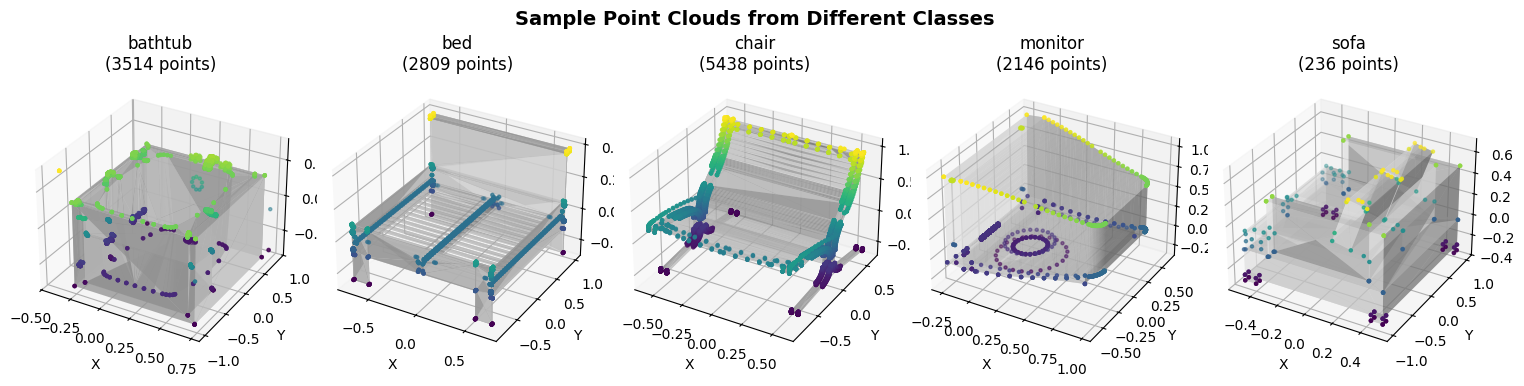

In [9]:
# Visualize sample point clouds
# Select diverse samples (one from each of 3 classes)
sample_indices = [0, 500, 1000, 2000, 3000]  # Assuming different classes

fig = plt.figure(figsize=(15, 4))
for idx, sample_idx in enumerate(sample_indices):
    data = dataset[sample_idx]
    ax = fig.add_subplot(1, len(sample_indices), idx + 1, projection="3d")
    pos = data.pos
    face = data.face
    colors = pos[:, 2]  # Color by height
    ax.plot_trisurf(
        pos[:, 0],
        pos[:, 1],
        pos[:, 2],
        triangles=face.t(),
        antialiased=True,
        color="white",
        alpha=0.5,
    )
    scatter = ax.scatter(
        pos[:, 0], pos[:, 1], pos[:, 2], c=colors, cmap="viridis", s=5
    )

    class_name = class_names[data.y.item()]
    ax.set_title(f"{class_name}\n({pos.shape[0]} points)")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")

plt.suptitle(
    "Sample Point Clouds from Different Classes", fontsize=14, weight="bold"
)
plt.tight_layout()
plt.show()

In [10]:
# Analyze point cloud properties
print("Point Cloud Properties:")
print("\n1. Unordered - No inherent ordering")
print("   Two permutations of the same point cloud should produce same result")

data = dataset[0]
print(f"\n2. Original point cloud shape: {data.pos.shape}")

# Permute points
perm_idx = torch.randperm(data.pos.shape[0])
permuted_pos = data.pos[perm_idx]
print(f"   Permuted point cloud shape: {permuted_pos.shape}")
print(
    f"   Distance between original and permuted: {torch.norm(data.pos - permuted_pos[torch.argsort(perm_idx)]):.6f}"
)

print(f"\n3. Bounding box:")
print(f"   X range: [{data.pos[:, 0].min():.2f}, {data.pos[:, 0].max():.2f}]")
print(f"   Y range: [{data.pos[:, 1].min():.2f}, {data.pos[:, 1].max():.2f}]")
print(f"   Z range: [{data.pos[:, 2].min():.2f}, {data.pos[:, 2].max():.2f}]")

Point Cloud Properties:

1. Unordered - No inherent ordering
   Two permutations of the same point cloud should produce same result

2. Original point cloud shape: torch.Size([3514, 3])
   Permuted point cloud shape: torch.Size([3514, 3])
   Distance between original and permuted: 0.000000

3. Bounding box:
   X range: [-0.42, 0.73]
   Y range: [-1.00, 0.87]
   Z range: [-0.76, 0.69]


## Section 3: Data Preprocessing Pipeline

Raw point clouds need preprocessing before feeding to neural networks. Common steps include:

1. **Normalization**: Scale point cloud to standard size/position
2. **Sampling**: Reduce/fix number of points for consistent batch processing
3. **Rotation**: Data augmentation (rotating point clouds)


Transform 1: NormalizeScale()
  Normalizes point cloud to unit sphere (all points within radius 1 of origin)

  Before normalization:
    Bounding box X: [-18.51, 18.51]
    Bounding box Y: [-30.03, 30.03]
    Bounding box Z: [-23.29, 23.29]
    Number of points: 3514

  After normalization:
    Bounding box X: [-0.42, 0.73]
    Bounding box Y: [-1.00, 0.87]
    Bounding box Z: [-0.76, 0.69]


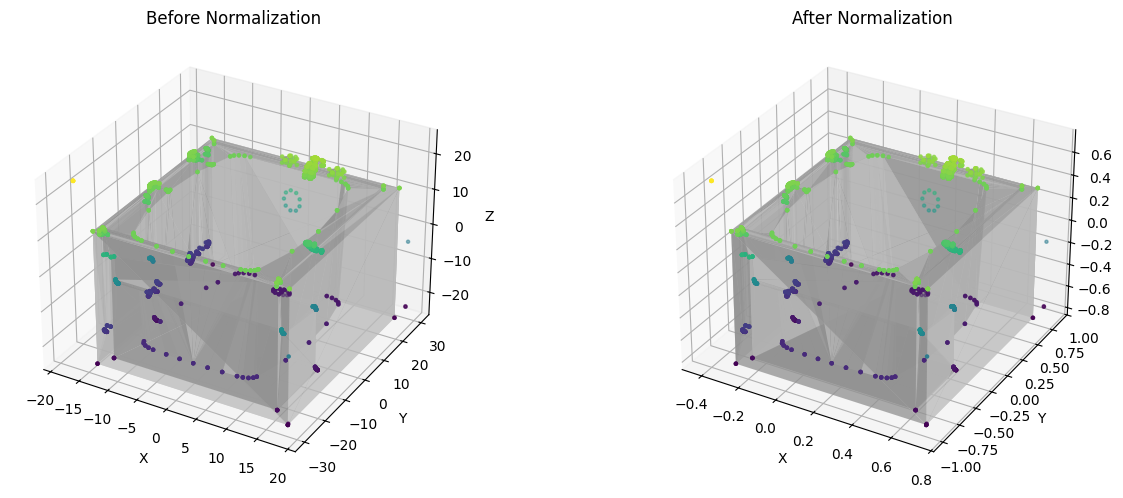

    Number of points: 3514


In [11]:
# Create preprocessing transforms
from torch_geometric.transforms import Compose

# Transform 1: Normalize to unit sphere
print("Transform 1: NormalizeScale()")
print(
    "  Normalizes point cloud to unit sphere (all points within radius 1 of origin)"
)

data = ModelNet("data/ModelNet10", name="10", train=True, transform=None)[0]
print(f"\n  Before normalization:")
print(
    f"    Bounding box X: [{data.pos[:, 0].min():.2f}, {data.pos[:, 0].max():.2f}]"
)
print(
    f"    Bounding box Y: [{data.pos[:, 1].min():.2f}, {data.pos[:, 1].max():.2f}]"
)
print(
    f"    Bounding box Z: [{data.pos[:, 2].min():.2f}, {data.pos[:, 2].max():.2f}]"
)
print(f"    Number of points: {data.pos.shape[0]}")

# Apply normalization
normalized_data = NormalizeScale()(data.clone())
print(f"\n  After normalization:")
print(
    f"    Bounding box X: [{normalized_data.pos[:, 0].min():.2f}, {normalized_data.pos[:, 0].max():.2f}]"
)
print(
    f"    Bounding box Y: [{normalized_data.pos[:, 1].min():.2f}, {normalized_data.pos[:, 1].max():.2f}]"
)
print(
    f"    Bounding box Z: [{normalized_data.pos[:, 2].min():.2f}, {normalized_data.pos[:, 2].max():.2f}]"
)

# Visualize normalization effect
fig = plt.figure(figsize=(14, 5))

# Before
ax1 = fig.add_subplot(121, projection="3d")
pos_before = data.pos.numpy()
face_before = data.face
ax1.plot_trisurf(
    pos_before[:, 0],
    pos_before[:, 1],
    pos_before[:, 2],
    triangles=face_before.t(),
    antialiased=True,
    color="white",
    alpha=0.5,
)
scatter1 = ax1.scatter(
    pos_before[:, 0],
    pos_before[:, 1],
    pos_before[:, 2],
    c=pos_before[:, 2],
    cmap="viridis",
    s=5,
)
ax1.set_title("Before Normalization")
ax1.set_xlabel("X")
ax1.set_ylabel("Y")
ax1.set_zlabel("Z")

# After
ax2 = fig.add_subplot(122, projection="3d")
pos_after = normalized_data.pos.numpy()
face_after = data.face
ax2.plot_trisurf(
    pos_after[:, 0],
    pos_after[:, 1],
    pos_after[:, 2],
    triangles=face_after.t(),
    antialiased=True,
    color="white",
    alpha=0.5,
)
scatter2 = ax2.scatter(
    pos_after[:, 0],
    pos_after[:, 1],
    pos_after[:, 2],
    c=pos_after[:, 2],
    cmap="viridis",
    s=5,
)
ax2.set_title("After Normalization")
ax2.set_xlabel("X")
ax2.set_ylabel("Y")
ax2.set_zlabel("Z")

plt.tight_layout()
plt.show()


print(f"    Number of points: {normalized_data.pos.shape[0]}")

In [12]:
# Transform 2: Sample fixed number of points
print("Transform 2: SamplePoints(1024)")
print("  Uniformly samples 1024 points from the point cloud")
print("  Ensures all point clouds have same number of points for batching")

sampler = SamplePoints(1024)
sampled_data = sampler(normalized_data.clone())

print(f"\n  Before sampling: {normalized_data.pos.shape[0]} points")
print(f"  After sampling: {sampled_data.pos.shape[0]} points")

Transform 2: SamplePoints(1024)
  Uniformly samples 1024 points from the point cloud
  Ensures all point clouds have same number of points for batching

  Before sampling: 3514 points
  After sampling: 1024 points


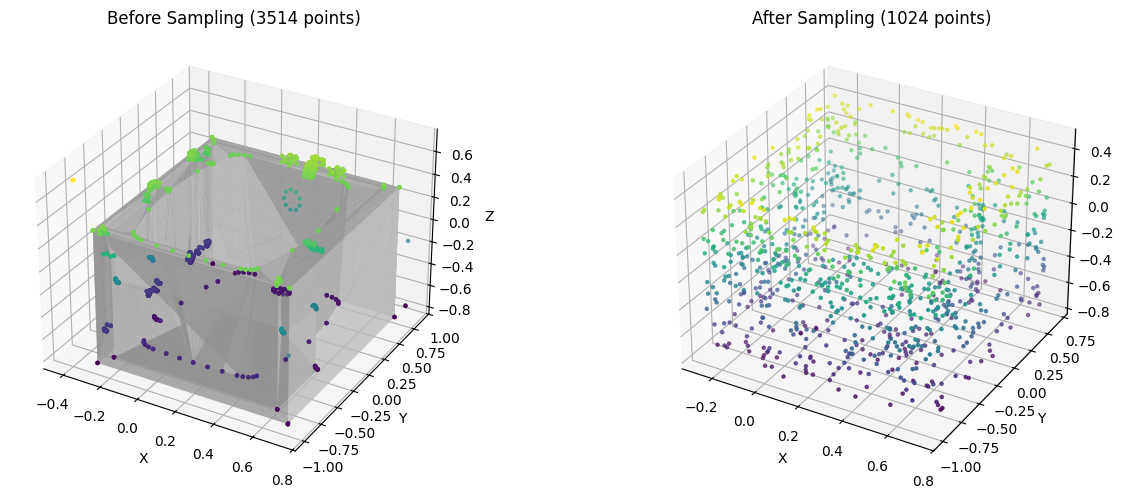


Point density reduction: 3514 → 1024
Compression ratio: 29.1%


In [13]:
# Visualize sampling effect
fig = plt.figure(figsize=(14, 5))

# Before sampling
ax1 = fig.add_subplot(121, projection="3d")
pos_before_sample = normalized_data.pos.numpy()
face_before_sample = normalized_data.face
ax1.plot_trisurf(
    pos_before_sample[:, 0],
    pos_before_sample[:, 1],
    pos_before_sample[:, 2],
    triangles=face_before_sample.t(),
    antialiased=True,
    color="white",
    alpha=0.5,
)
scatter1 = ax1.scatter(
    pos_before_sample[:, 0],
    pos_before_sample[:, 1],
    pos_before_sample[:, 2],
    c=pos_before_sample[:, 2],
    cmap="viridis",
    s=5,
    alpha=0.6,
)
ax1.set_title(f"Before Sampling ({pos_before_sample.shape[0]} points)")
ax1.set_xlabel("X")
ax1.set_ylabel("Y")
ax1.set_zlabel("Z")

# After sampling
ax2 = fig.add_subplot(122, projection="3d")
pos_after_sample = sampled_data.pos.numpy()
scatter2 = ax2.scatter(
    pos_after_sample[:, 0],
    pos_after_sample[:, 1],
    pos_after_sample[:, 2],
    c=pos_after_sample[:, 2],
    cmap="viridis",
    s=5,
)
ax2.set_title(f"After Sampling ({pos_after_sample.shape[0]} points)")
ax2.set_xlabel("X")
ax2.set_ylabel("Y")
ax2.set_zlabel("Z")

plt.tight_layout()
plt.show()

print(
    f"\nPoint density reduction: {normalized_data.pos.shape[0]} → {sampled_data.pos.shape[0]}"
)
print(
    f"Compression ratio: {sampled_data.pos.shape[0] / normalized_data.pos.shape[0]:.1%}"
)

In [14]:
# Create final dataset with complete preprocessing pipeline
preprocessing_transforms = Compose([NormalizeScale(), SamplePoints(1024)])

print("Creating datasets with complete preprocessing pipeline...")
train_dataset = ModelNet(
    "data/ModelNet10", name="10", train=True, transform=preprocessing_transforms
)
test_dataset = ModelNet(
    "data/ModelNet10",
    name="10",
    train=False,
    transform=preprocessing_transforms,
)

print(f"Training set: {len(train_dataset)} samples")
print(f"Test set: {len(test_dataset)} samples")
print(f"Classes: {class_names}")

# Verify all point clouds have same shape
shapes = [train_dataset[i].pos.shape[0] for i in range(len(train_dataset))]
print(f"\nAll point clouds have 1024 points: {all(s == 1024 for s in shapes)}")

Creating datasets with complete preprocessing pipeline...
Training set: 3991 samples
Test set: 908 samples
Classes: ['bathtub', 'bed', 'chair', 'desk', 'dresser', 'monitor', 'night_stand', 'sofa', 'table', 'toilet']

All point clouds have 1024 points: True


## Section 4: PointNet++ Architecture

PointNet++ uses hierarchical layers called **Set Abstraction (SA) modules** to progressively downsample and extract features from point clouds.

### Key Concepts for Survey Engineers

- **Set Abstraction (SA)** = Hierarchical sampling (like Level of Detail in GIS)
- **Farthest Point Sampling (FPS)** = Optimal spatial coverage (like survey station placement)
- **Radius search** = Local neighborhood analysis (like TIN triangulation)


In [15]:
import os.path as osp

import torch
import torch.nn.functional as F

import torch_geometric.transforms as T
from torch_geometric.datasets import ModelNet
from torch_geometric.loader import DataLoader
from torch_geometric.nn import MLP, PointNetConv, fps, global_max_pool, radius
from torch_geometric.typing import WITH_TORCH_CLUSTER

if not WITH_TORCH_CLUSTER:
    quit("This example requires 'torch-cluster'")


class SAModule(torch.nn.Module):
    def __init__(self, ratio, r, nn):
        super().__init__()
        self.ratio = ratio
        self.r = r
        self.conv = PointNetConv(nn, add_self_loops=False)

    def forward(self, x, pos, batch):
        idx = fps(pos, batch, ratio=self.ratio)
        row, col = radius(
            pos, pos[idx], self.r, batch, batch[idx], max_num_neighbors=64
        )
        edge_index = torch.stack([col, row], dim=0)
        x_dst = None if x is None else x[idx]
        x = self.conv((x, x_dst), (pos, pos[idx]), edge_index)
        pos, batch = pos[idx], batch[idx]
        return x, pos, batch


class GlobalSAModule(torch.nn.Module):
    def __init__(self, nn):
        super().__init__()
        self.nn = nn

    def forward(self, x, pos, batch):
        x = self.nn(torch.cat([x, pos], dim=1))
        x = global_max_pool(x, batch)
        pos = pos.new_zeros((x.size(0), 3))
        batch = torch.arange(x.size(0), device=batch.device)
        return x, pos, batch


class Net(torch.nn.Module):
    """PointNet++ model for classification"""

    def __init__(self, num_classes):
        super().__init__()

        # Set Abstraction Layer 1: 1024 points → 512 points
        self.sa1_module = SAModule(ratio=0.5, r=0.2, nn=MLP([3, 64, 64, 128]))

        # Set Abstraction Layer 2: 512 points → 128 points
        self.sa2_module = SAModule(
            ratio=0.25, r=0.4, nn=MLP([128 + 3, 128, 128, 256])
        )

        # Global Set Abstraction: 128 points → 1 global descriptor
        self.sa3_module = GlobalSAModule(nn=MLP([256 + 3, 256, 512, 1024]))

        # Classification head
        self.mlp = MLP([1024, 512, 256, num_classes], dropout=0.5, norm=None)

    def forward(self, data):
        sa0_out = (data.x, data.pos, data.batch)
        sa1_out = self.sa1_module(*sa0_out)
        sa2_out = self.sa2_module(*sa1_out)
        sa3_out = self.sa3_module(*sa2_out)
        x, pos, batch = sa3_out

        return self.mlp(x).log_softmax(dim=-1)


print("✅ PointNet++ architecture defined")

✅ PointNet++ architecture defined


In [16]:
# Create model and print summary
model = Net(num_classes=len(class_names)).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Model Architecture:")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"\nModel structure:")
print(model)

Model Architecture:
  Total parameters: 1,463,626
  Trainable parameters: 1,463,626

Model structure:
Net(
  (sa1_module): SAModule(
    (conv): PointNetConv(local_nn=MLP(3, 64, 64, 128), global_nn=None)
  )
  (sa2_module): SAModule(
    (conv): PointNetConv(local_nn=MLP(131, 128, 128, 256), global_nn=None)
  )
  (sa3_module): GlobalSAModule(
    (nn): MLP(259, 256, 512, 1024)
  )
  (mlp): MLP(1024, 512, 256, 10)
)


In [17]:
from torch.utils.data import random_split

train_dataset, val_dataset = random_split(train_dataset, lengths=[0.6, 0.4])

# Create data loaders
train_loader = DataLoader(
    train_dataset, batch_size=32, shuffle=True, num_workers=4
)
val_loader = DataLoader(
    val_dataset, batch_size=32, shuffle=False, num_workers=4
)
test_loader = DataLoader(
    test_dataset, batch_size=32, shuffle=False, num_workers=4
)

# Verify data loading
sample_batch = next(iter(train_loader))
print(f"Sample batch properties:")
print(f"  Batch size: {sample_batch.batch.max().item() + 1}")
print(f"  Total points: {sample_batch.pos.shape[0]}")
print(f"  Labels: {sample_batch.y.shape}")
print(f"  Classes in batch: {[class_names[y] for y in sample_batch.y]}")

Sample batch properties:
  Batch size: 32
  Total points: 32768
  Labels: torch.Size([32])
  Classes in batch: ['desk', 'table', 'chair', 'chair', 'desk', 'sofa', 'chair', 'sofa', 'bathtub', 'sofa', 'monitor', 'monitor', 'bathtub', 'monitor', 'chair', 'chair', 'chair', 'table', 'dresser', 'table', 'bed', 'desk', 'monitor', 'table', 'bathtub', 'sofa', 'chair', 'sofa', 'chair', 'sofa', 'bathtub', 'table']


## Section 5: Training the Model

We'll train the model for 30 epochs (quick training for demonstration). The training will take approximately 15-20 minutes on a Colab GPU.


In [18]:
# Setup optimizer and loss function
optimizer = Adam(model.parameters(), lr=0.001)
criterion = torch.nn.NLLLoss()


def train_epoch(model, loader, optimizer, device):
    """Train for one epoch"""
    model.train()
    total_loss = 0

    for data in tqdm(loader, total=len(loader)):
        data = data.to(device)
        optimizer.zero_grad()
        out = model(data)
        loss = criterion(out, data.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(loader)


def evaluate(model, loader, device, criterion=None):
    """Evaluate model on validation/test set, returns (accuracy, loss)"""
    model.eval()
    correct = 0
    total = 0
    total_loss = 0

    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            out = model(data)
            pred = out.argmax(dim=1)
            correct += (pred == data.y).sum().item()
            total += data.y.size(0)

            if criterion is not None:
                loss = criterion(out, data.y)
                total_loss += loss.item()

    accuracy = correct / total
    avg_loss = total_loss / len(loader) if criterion is not None else None

    return accuracy, avg_loss


print("✅ Training utilities defined")

✅ Training utilities defined


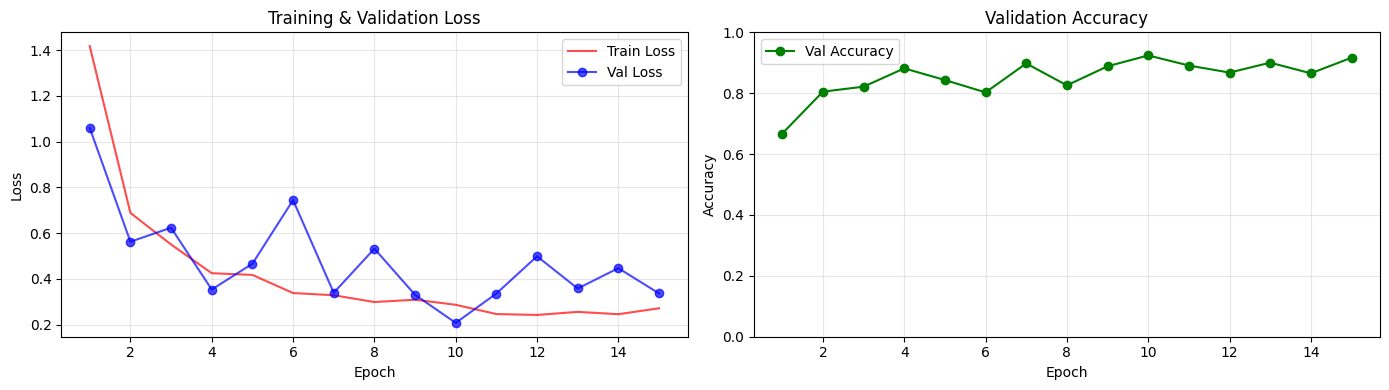


✅ Training complete!
Best validation accuracy: 0.9242


In [19]:
# Training loop with live visualization
import matplotlib.pyplot as plt
from IPython.display import clear_output

num_epochs = 15
train_losses = []
val_losses = []
val_accs = []
eval_epochs = []

best_acc = 0
best_model_state = None

print(f"Training PointNet++ on {device}...")
print(f"Epochs: {num_epochs}, Batch size: 32")
print(f"Expected training time: 15-20 minutes on GPU\n")

for epoch in range(1, num_epochs + 1):
    loss = train_epoch(model, train_loader, optimizer, device)
    train_losses.append(loss)

    val_acc, val_loss = evaluate(model, val_loader, device, criterion=criterion)
    val_accs.append(val_acc)
    val_losses.append(val_loss)
    eval_epochs.append(epoch)

    if val_acc > best_acc:
        best_acc = val_acc
        best_model_state = model.state_dict().copy()

    print(
        f"Epoch {epoch:2d}/{num_epochs} | Train Loss: {loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
    )

    # Plot progress
    if epoch % 10 == 0 or epoch == num_epochs:
        clear_output(wait=True)
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

        # Training and Validation Loss
        ax1.plot(
            range(1, len(train_losses) + 1),
            train_losses,
            "r-",
            label="Train Loss",
            alpha=0.7,
        )
        ax1.plot(eval_epochs, val_losses, "b-o", label="Val Loss", alpha=0.7)
        ax1.set_xlabel("Epoch")
        ax1.set_ylabel("Loss")
        ax1.set_title("Training & Validation Loss")
        ax1.legend()
        ax1.grid(True, alpha=0.3)

        # Validation Accuracy
        ax2.plot(eval_epochs, val_accs, "g-o", label="Val Accuracy")
        ax2.set_xlabel("Epoch")
        ax2.set_ylabel("Accuracy")
        ax2.set_title("Validation Accuracy")
        ax2.set_ylim([0, 1])
        ax2.legend()
        ax2.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

# Load best model
if best_model_state:
    model.load_state_dict(best_model_state)

print(f"\n✅ Training complete!")
print(f"Best validation accuracy: {best_acc:.4f}")

## Section 6: Feature Visualization

Let's visualize what features the model learns at different layers.


In [20]:
# Extract intermediate features using forward hooks
activations = {}


def get_activation(name):
    def hook(model, input, output):
        # SAModule returns tuple (x, pos, batch), extract only the features
        if isinstance(output, tuple):
            activations[name] = output[0].detach()
        else:
            activations[name] = output.detach()

    return hook


# Register hooks to capture layer outputs
model.sa1_module.register_forward_hook(get_activation("sa1"))
model.sa2_module.register_forward_hook(get_activation("sa2"))
model.sa3_module.register_forward_hook(get_activation("sa3"))

print("✅ Forward hooks registered for feature extraction")

✅ Forward hooks registered for feature extraction


In [50]:
len(train_loader)

75

In [51]:
# Extract features from test samples
model.eval()
feature_data = {"sa1": [], "sa2": [], "sa3": [], "labels": [], "positions": []}

with torch.no_grad():
    for data in test_loader:
        data = data.to(device)
        _ = model(data)

        # Store features and metadata
        if "sa1" in activations:
            feature_data["sa1"].append(activations["sa1"].cpu())
        if "sa2" in activations:
            feature_data["sa2"].append(activations["sa2"].cpu())
        if "sa3" in activations:
            feature_data["sa3"].append(activations["sa3"].cpu())

        feature_data["labels"].append(data.y.cpu())
        feature_data["positions"].append(data.pos.cpu())

        # if len(feature_data["sa3"]) >= 5:  # Collect first 5 batches
        #     break

# Concatenate
for key in ["sa1", "sa2", "sa3"]:
    feature_data[key] = torch.cat(feature_data[key], dim=0)
feature_data["labels"] = torch.cat(feature_data["labels"], dim=0)

print(f"Feature dimensions:")
print(f"  SA1: {feature_data['sa1'].shape}")
print(f"  SA2: {feature_data['sa2'].shape}")
print(f"  SA3: {feature_data['sa3'].shape}")

Feature dimensions:
  SA1: torch.Size([464896, 128])
  SA2: torch.Size([116224, 256])
  SA3: torch.Size([908, 1024])


In [52]:
feature_data["labels"]

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
        3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
        3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,

In [53]:
# Visualize SA1 and SA2 features as point cloud colors
from sklearn.decomposition import PCA

print("Visualizing SA1 and SA2 features as 3D point cloud colors...\n")

# Get SA1, SA2, SA3 features
sa1_feat = feature_data["sa1"][:5].numpy()
sa2_feat = feature_data["sa2"][:5].numpy()
sa3_feat = feature_data["sa3"][:5].numpy()

print(f"SA1 features shape: {sa1_feat.shape}")
print(f"SA2 features shape: {sa2_feat.shape}")
print(f"SA3 features shape: {sa3_feat.shape}")

# Apply PCA to get 3D RGB colors
pca_sa1 = PCA(n_components=3)
sa1_colors = pca_sa1.fit_transform(sa1_feat)
sa1_colors = (sa1_colors - sa1_colors.min(axis=0)) / (
    sa1_colors.max(axis=0) - sa1_colors.min(axis=0)
)

pca_sa2 = PCA(n_components=3)
sa2_colors = pca_sa2.fit_transform(sa2_feat)
sa2_colors = (sa2_colors - sa2_colors.min(axis=0)) / (
    sa2_colors.max(axis=0) - sa2_colors.min(axis=0)
)

pca_sa3 = PCA(n_components=3)
sa3_colors = pca_sa3.fit_transform(sa3_feat)
sa3_colors = (sa3_colors - sa3_colors.min(axis=0)) / (
    sa3_colors.max(axis=0) - sa3_colors.min(axis=0)
)

print(f"SA1 RGB shape: {sa1_colors.shape}")
print(f"SA2 RGB shape: {sa2_colors.shape}")
print(f"SA3 RGB shape: {sa3_colors.shape}")

Visualizing SA1 and SA2 features as 3D point cloud colors...

SA1 features shape: (5, 128)
SA2 features shape: (5, 256)
SA3 features shape: (5, 1024)
SA1 RGB shape: (5, 3)
SA2 RGB shape: (5, 3)
SA3 RGB shape: (5, 3)


Computing t-SNE for global features...
[0 1 2 3 4 5 6 7 8 9]


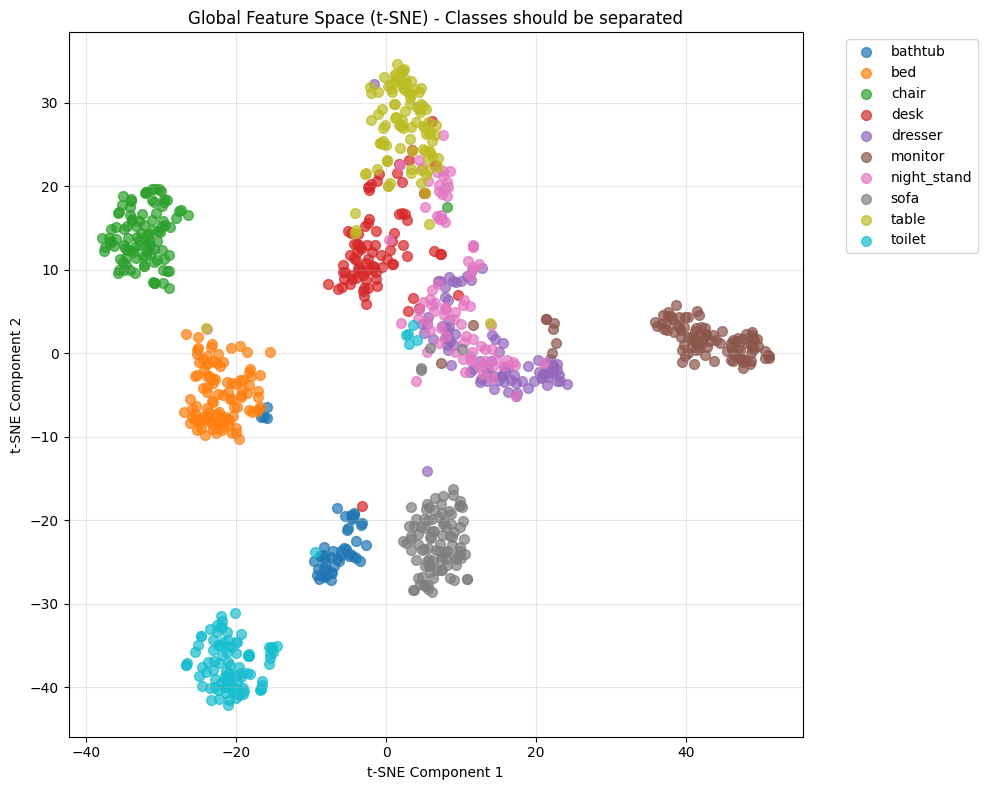

✅ Feature visualization complete


In [54]:
# Visualize global features with t-SNE
from sklearn.manifold import TSNE

print("Computing t-SNE for global features...")
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
features_tsne = tsne.fit_transform(feature_data["sa3"].numpy())

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
labels = feature_data["labels"].numpy()
print(np.unique(labels))
for idx, class_name in enumerate(class_names):
    mask = labels == idx
    ax.scatter(
        features_tsne[mask, 0],
        features_tsne[mask, 1],
        label=class_name,
        s=50,
        alpha=0.7,
    )

ax.set_xlabel("t-SNE Component 1")
ax.set_ylabel("t-SNE Component 2")
ax.set_title("Global Feature Space (t-SNE) - Classes should be separated")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("✅ Feature visualization complete")

## Section 7: Results & Analysis

Evaluate the trained model and analyze predictions.


In [26]:
# Comprehensive evaluation on test set
model.eval()
test_acc, test_loss = evaluate(model, test_loader, device, criterion=criterion)
print(f"Test Set Results:")
print(f"  Loss: {test_loss:.4f}")
print(f"  Accuracy: {test_acc:.4f}")

all_preds = []
all_targets = []
all_confidences = []

with torch.no_grad():
    for data in test_loader:
        data = data.to(device)
        out = model(data)
        pred = out.argmax(dim=1)
        conf = out.softmax(dim=1).max(dim=1).values

        all_preds.extend(pred.cpu().numpy())
        all_targets.extend(data.y.cpu().numpy())
        all_confidences.extend(conf.cpu().numpy())

all_preds = np.array(all_preds)
all_targets = np.array(all_targets)
all_confidences = np.array(all_confidences)

# Overall accuracy
overall_acc = (all_preds == all_targets).mean()
print(f"\nOverall Test Accuracy: {overall_acc:.4f}")

Test Set Results:
  Loss: 0.4573
  Accuracy: 0.8623

Overall Test Accuracy: 0.8733


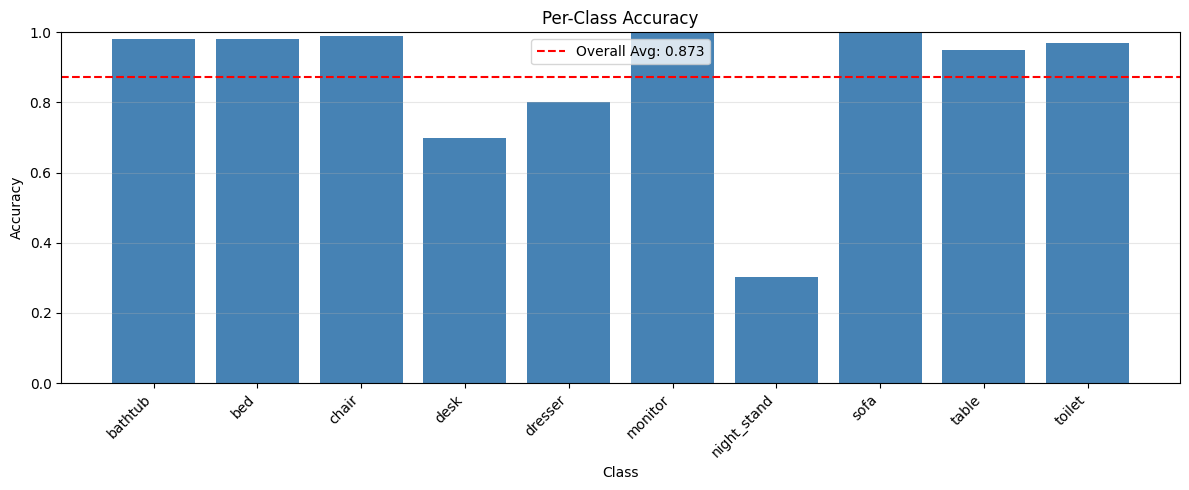

Per-class accuracy:
  bathtub: 0.9800
  bed: 0.9800
  chair: 0.9900
  desk: 0.6977
  dresser: 0.8023
  monitor: 1.0000
  night_stand: 0.3023
  sofa: 1.0000
  table: 0.9500
  toilet: 0.9700


In [27]:
# Per-class accuracy
fig, ax = plt.subplots(figsize=(12, 5))
per_class_acc = []

for idx, class_name in enumerate(class_names):
    mask = all_targets == idx
    if mask.sum() > 0:
        acc = (all_preds[mask] == all_targets[mask]).mean()
        per_class_acc.append(acc)
    else:
        per_class_acc.append(0)

bars = ax.bar(class_names, per_class_acc, color="steelblue")
ax.axhline(
    y=overall_acc,
    color="r",
    linestyle="--",
    label=f"Overall Avg: {overall_acc:.3f}",
)
ax.set_ylabel("Accuracy")
ax.set_xlabel("Class")
ax.set_title("Per-Class Accuracy")
ax.set_ylim([0, 1])
ax.legend()
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print("Per-class accuracy:")
for idx, class_name in enumerate(class_names):
    print(f"  {class_name}: {per_class_acc[idx]:.4f}")


Showing 36 random correct predictions:


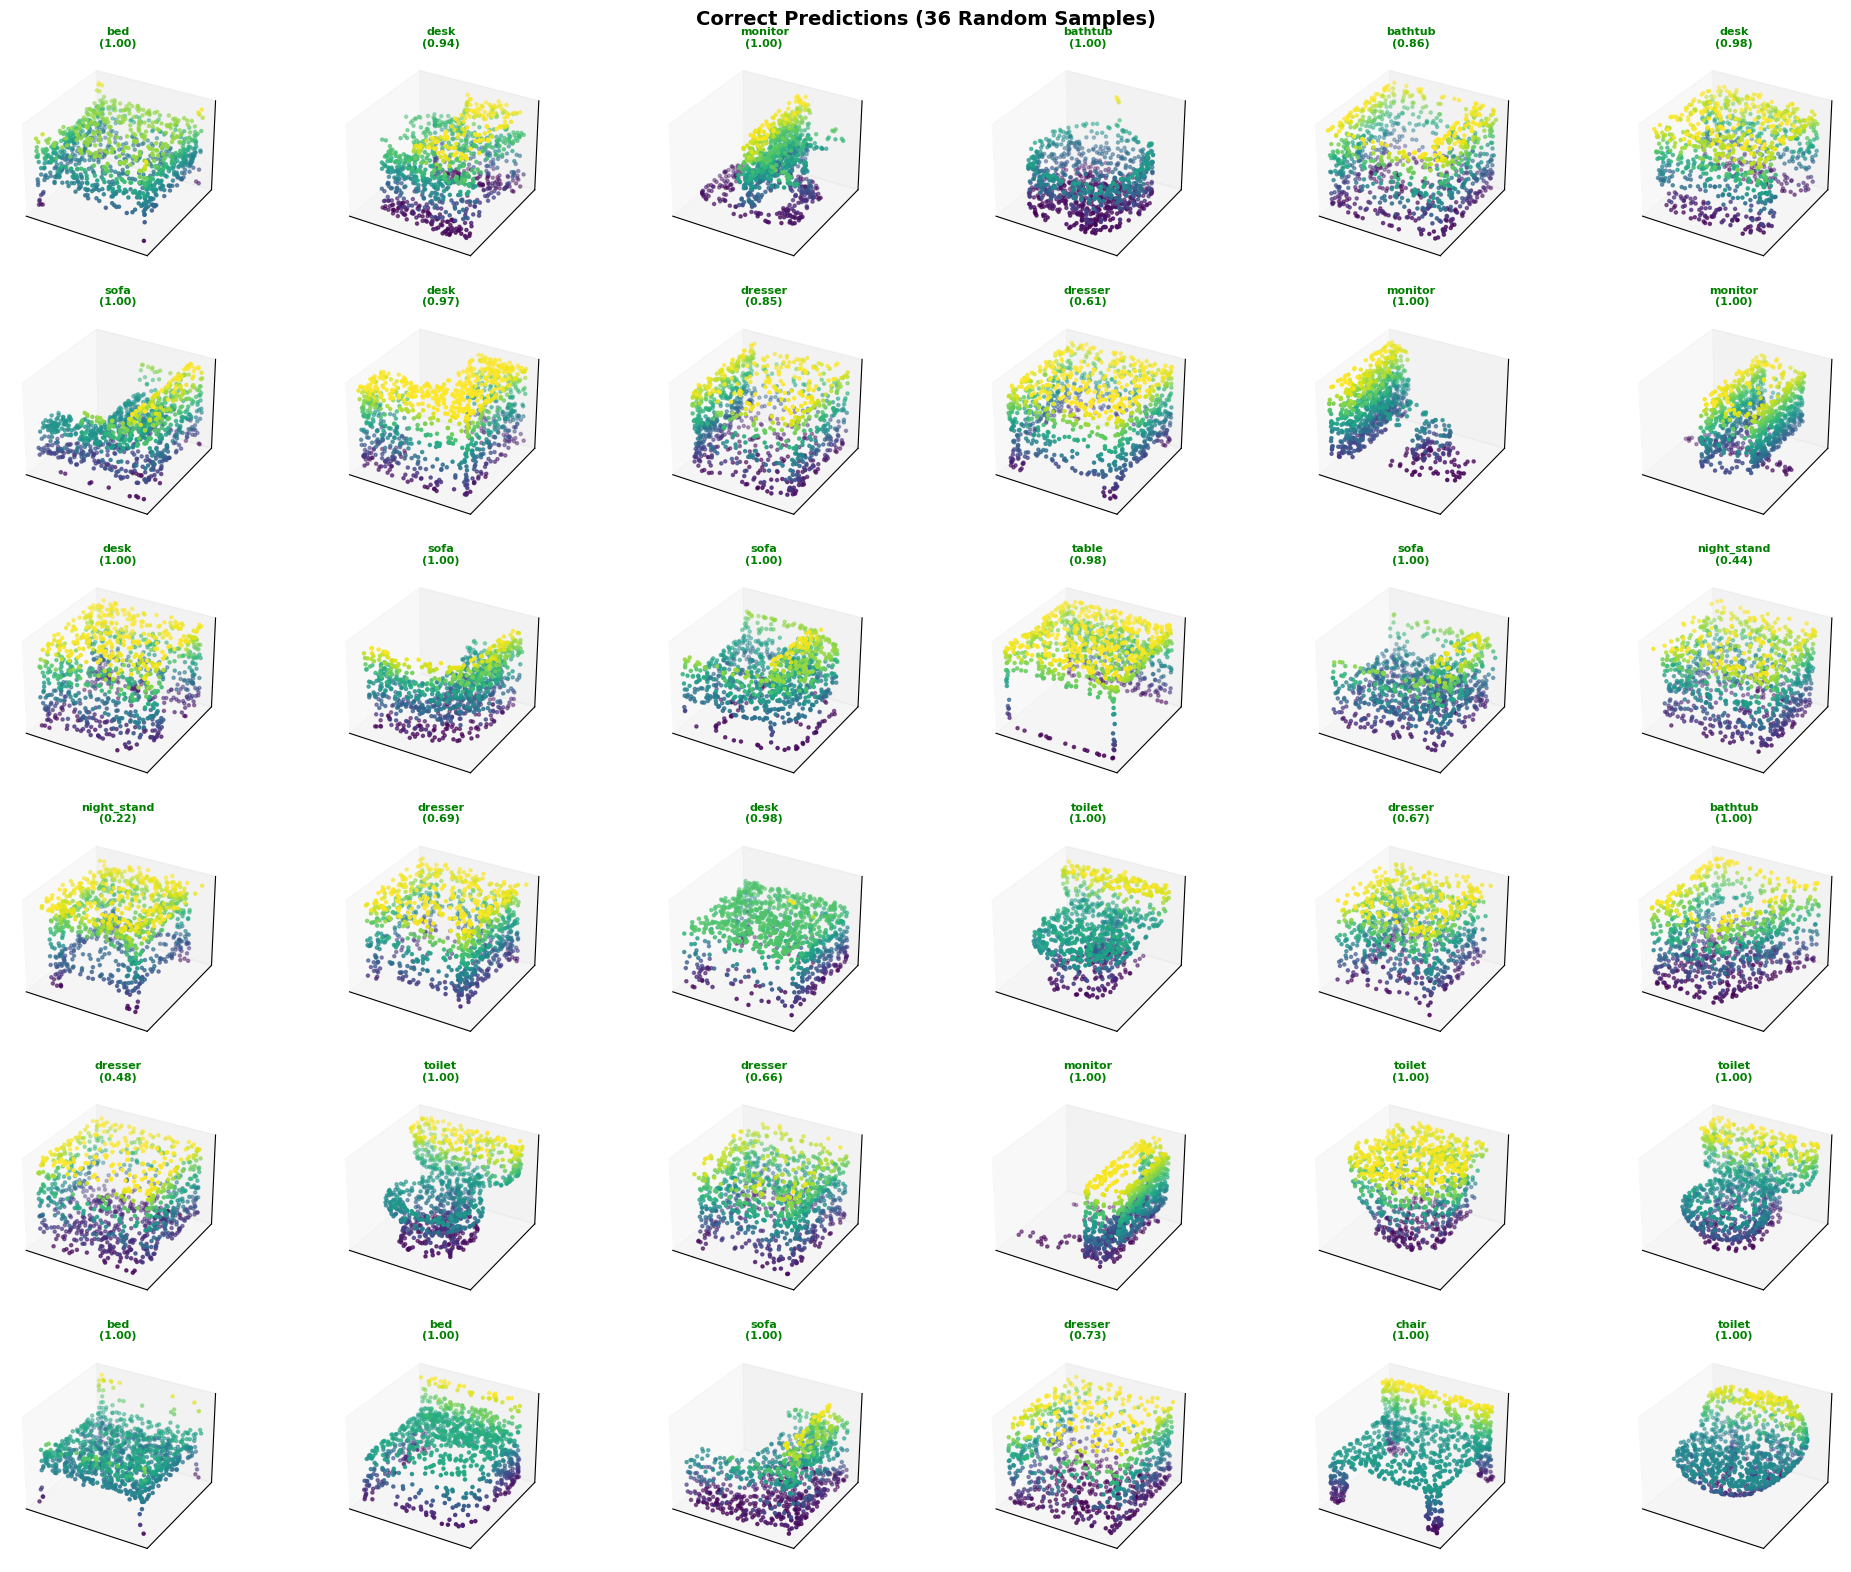

In [28]:
# Analyze correct predictions - 36 random samples
print("\nShowing 36 random correct predictions:")
print("=" * 60)

# Get samples
correct_indices = np.where(all_preds == all_targets)[0]
if len(correct_indices) > 36:
    selected_correct = np.random.choice(correct_indices, size=36, replace=False)
else:
    selected_correct = correct_indices

fig = plt.figure(figsize=(20, 16))
for plot_idx, test_idx in enumerate(selected_correct):
    ax = fig.add_subplot(6, 6, plot_idx + 1, projection="3d")

    # Get the sample
    sample_idx_in_loader = 0
    current_count = 0
    for batch_idx, batch in enumerate(test_loader):
        if current_count + len(batch.y) > test_idx:
            sample_idx_in_loader = test_idx - current_count
            batch_data = batch[sample_idx_in_loader]
            break
        current_count += len(batch.y)

    pos = batch_data.pos.numpy()
    ax.scatter(
        pos[:, 0], pos[:, 1], pos[:, 2], c=pos[:, 2], cmap="viridis", s=5
    )

    pred_idx = all_preds[test_idx]
    true_idx = all_targets[test_idx]
    conf = all_confidences[test_idx]

    ax.set_title(
        f"{class_names[pred_idx]}\n({conf:.2f})",
        color="green",
        weight="bold",
        fontsize=8,
    )
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])

plt.suptitle(
    "Correct Predictions (36 Random Samples)", fontsize=14, weight="bold"
)
plt.tight_layout()
plt.show()


Showing 36 random incorrect predictions:


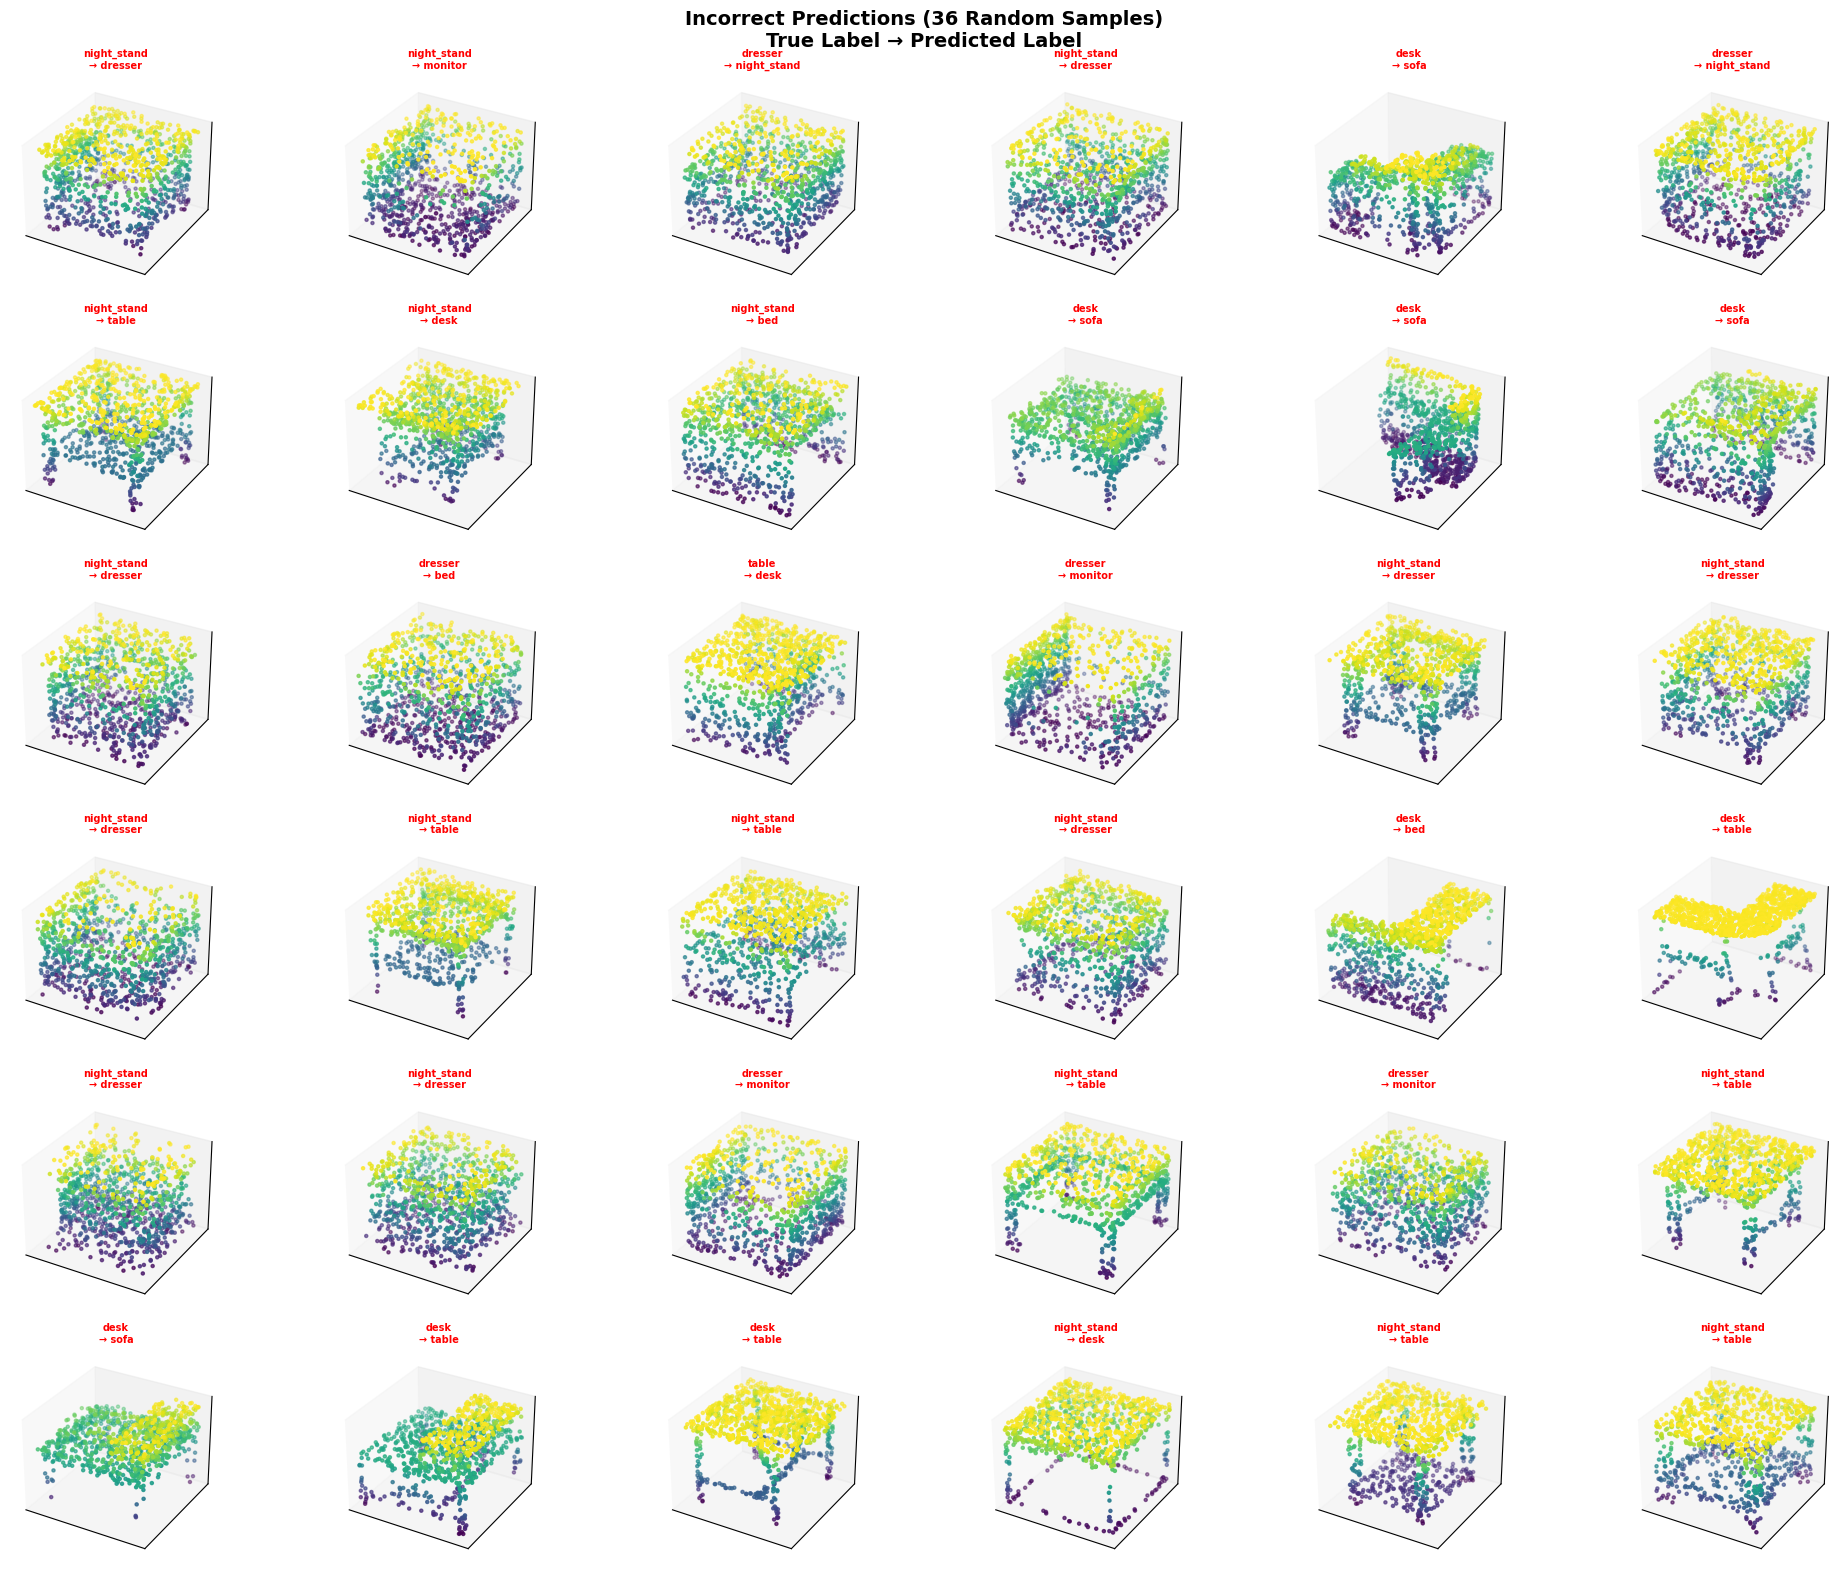

In [29]:
# Analyze incorrect predictions - 36 random samples
print("\nShowing 36 random incorrect predictions:")
print("=" * 60)

incorrect_indices = np.where(all_preds != all_targets)[0]
if len(incorrect_indices) > 0:
    if len(incorrect_indices) > 36:
        selected_incorrect = np.random.choice(
            incorrect_indices, size=36, replace=False
        )
    else:
        selected_incorrect = incorrect_indices

    fig = plt.figure(figsize=(20, 16))
    for plot_idx, test_idx in enumerate(selected_incorrect):
        ax = fig.add_subplot(6, 6, plot_idx + 1, projection="3d")

        # Get the sample
        sample_idx_in_loader = 0
        current_count = 0
        for batch_idx, batch in enumerate(test_loader):
            if current_count + len(batch.y) > test_idx:
                sample_idx_in_loader = test_idx - current_count
                batch_data = batch[sample_idx_in_loader]
                break
            current_count += len(batch.y)

        pos = batch_data.pos.numpy()
        ax.scatter(
            pos[:, 0], pos[:, 1], pos[:, 2], c=pos[:, 2], cmap="viridis", s=5
        )

        pred_idx = all_preds[test_idx]
        true_idx = all_targets[test_idx]
        conf = all_confidences[test_idx]

        # Show true label on top, predicted below
        title_text = f"{class_names[true_idx]}\n→ {class_names[pred_idx]}"
        ax.set_title(title_text, color="red", weight="bold", fontsize=7)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_zticks([])

    plt.suptitle(
        "Incorrect Predictions (36 Random Samples)\nTrue Label → Predicted Label",
        fontsize=14,
        weight="bold",
    )
    plt.tight_layout()
    plt.show()
else:
    print("All predictions are correct! 🎉")


Showing correct predictions with high confidence:


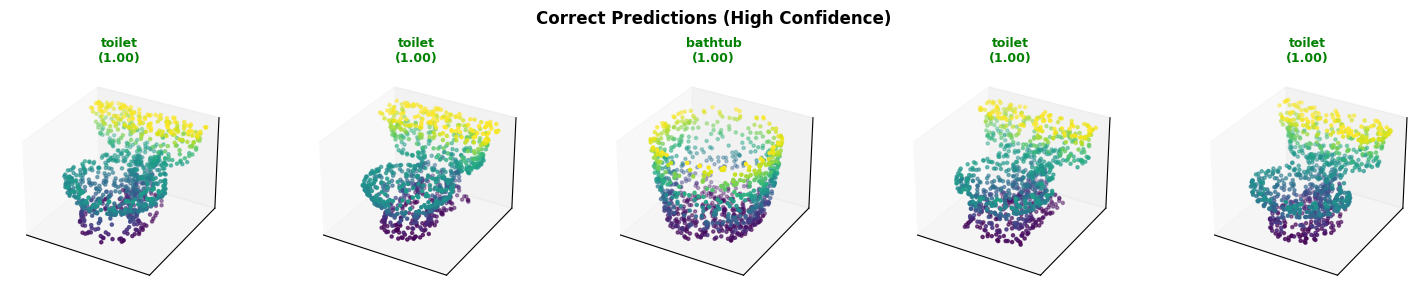

In [30]:
# Analyze correct predictions
print("\nShowing correct predictions with high confidence:")
print("=" * 60)

# Get samples
correct_indices = np.where(all_preds == all_targets)[0]
sorted_correct = correct_indices[
    np.argsort(-all_confidences[correct_indices])[:5]
]

fig = plt.figure(figsize=(15, 3))
for plot_idx, test_idx in enumerate(sorted_correct):
    ax = fig.add_subplot(1, 5, plot_idx + 1, projection="3d")

    # Get the sample
    sample_idx_in_loader = 0
    current_count = 0
    for batch_idx, batch in enumerate(test_loader):
        if current_count + len(batch.y) > test_idx:
            sample_idx_in_loader = test_idx - current_count
            batch_data = batch[sample_idx_in_loader]
            break
        current_count += len(batch.y)

    pos = batch_data.pos.numpy()
    ax.scatter(
        pos[:, 0], pos[:, 1], pos[:, 2], c=pos[:, 2], cmap="viridis", s=5
    )

    pred_idx = all_preds[test_idx]
    true_idx = all_targets[test_idx]
    conf = all_confidences[test_idx]

    ax.set_title(
        f"{class_names[pred_idx]}\n({conf:.2f})",
        color="green",
        weight="bold",
        fontsize=9,
    )
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])

plt.suptitle(
    "Correct Predictions (High Confidence)", fontsize=12, weight="bold"
)
plt.tight_layout()
plt.show()


Showing incorrect predictions:


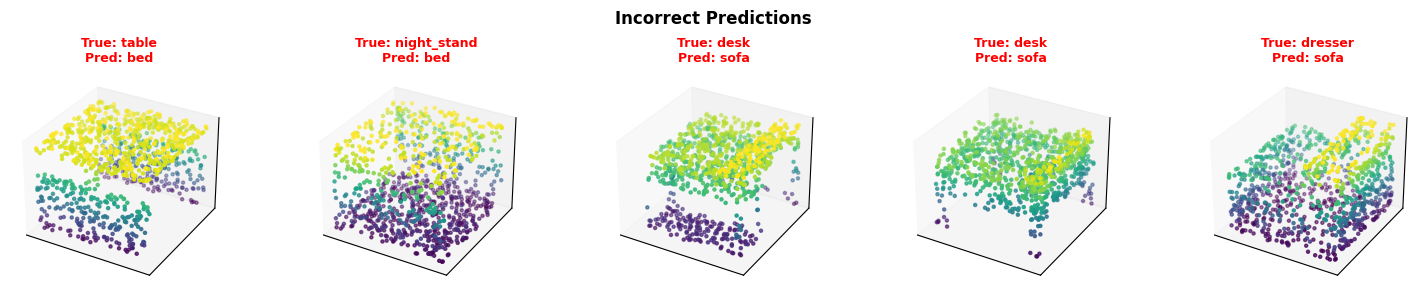

In [46]:
# Analyze incorrect predictions
print("\nShowing incorrect predictions:")
print("=" * 60)

incorrect_indices = np.where(all_preds != all_targets)[0]
if len(incorrect_indices) > 0:
    sorted_incorrect = incorrect_indices[
        np.argsort(-all_confidences[incorrect_indices])[:5]
    ]

    fig = plt.figure(figsize=(15, 3))
    for plot_idx, test_idx in enumerate(sorted_incorrect):
        ax = fig.add_subplot(1, 5, plot_idx + 1, projection="3d")

        # Get the sample
        sample_idx_in_loader = 0
        current_count = 0
        for batch_idx, batch in enumerate(test_loader):
            if current_count + len(batch.y) > test_idx:
                sample_idx_in_loader = test_idx - current_count
                batch_data = batch[sample_idx_in_loader]
                break
            current_count += len(batch.y)

        pos = batch_data.pos.numpy()
        ax.scatter(
            pos[:, 0], pos[:, 1], pos[:, 2], c=pos[:, 2], cmap="viridis", s=5
        )

        pred_idx = all_preds[test_idx]
        true_idx = all_targets[test_idx]
        conf = all_confidences[test_idx]

        title_text = (
            f"True: {class_names[true_idx]}\nPred: {class_names[pred_idx]}"
        )
        ax.set_title(title_text, color="red", weight="bold", fontsize=9)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_zticks([])

    plt.suptitle("Incorrect Predictions", fontsize=12, weight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("All predictions are correct! 🎉")

## Section 8: Interactive Exploration

Experiment with individual predictions and understand what the model learns.


In [32]:
# Interactive prediction interface
from ipywidgets import interact, IntSlider

test_samples = []
test_predictions = []

model.eval()
with torch.no_grad():
    for batch_idx, batch in enumerate(test_loader):
        batch = batch.to(device)
        out = model(batch)

        for i in range(len(batch.y)):
            test_samples.append(batch[i])
            test_predictions.append(
                {
                    "pred": out[i].argmax().cpu().item(),
                    "true": batch[i].y.item(),
                    "probs": F.softmax(out[i], dim=0).cpu().numpy(),
                }
            )

        if len(test_samples) >= 100:  # First 100 samples
            break

print(f"Loaded {len(test_samples)} test samples for interactive exploration")

Loaded 128 test samples for interactive exploration


In [33]:
class_names

['bathtub',
 'bed',
 'chair',
 'desk',
 'dresser',
 'monitor',
 'night_stand',
 'sofa',
 'table',
 'toilet']

In [34]:
# Interactive viewer
def view_sample(sample_idx=0):
    if sample_idx >= len(test_samples):
        print(f"Sample index out of range (max: {len(test_samples) - 1})")
        return

    sample = test_samples[sample_idx]
    pred = test_predictions[sample_idx]

    # 3D visualization
    fig = plt.figure(figsize=(14, 5))

    # Point cloud
    ax1 = fig.add_subplot(121, projection="3d")
    pos = sample.pos.cpu().numpy()
    scatter = ax1.scatter(
        pos[:, 0], pos[:, 1], pos[:, 2], c=pos[:, 2], cmap="viridis", s=10
    )
    ax1.set_xlabel("X")
    ax1.set_ylabel("Y")
    ax1.set_zlabel("Z")
    true_class = class_names[pred["true"]]
    ax1.set_title(f"True class: {true_class}")
    plt.colorbar(scatter, ax=ax1)

    # Prediction probabilities
    ax2 = fig.add_subplot(122)
    probs = pred["probs"]
    colors = [
        "green"
        if i == pred["pred"]
        else "red"
        if i == pred["true"]
        else "lightgray"
        for i in range(len(class_names))
    ]
    bars = ax2.barh(class_names, probs, color=colors)
    ax2.set_xlabel("Probability")
    ax2.set_title(
        f"Predicted: {class_names[pred['pred']]} (Confidence: {probs[pred['pred']].max():.3f})"
    )
    ax2.set_xlim([0, 1])

    # Add value labels
    for i, (bar, prob) in enumerate(zip(bars, probs)):
        ax2.text(prob + 0.02, i, f"{prob:.3f}", va="center")

    plt.tight_layout()
    plt.show()


# Create interactive slider
interact(
    view_sample,
    sample_idx=IntSlider(min=0, max=len(test_samples) - 1, step=1, value=0),
)

interactive(children=(IntSlider(value=0, description='sample_idx', max=127), Output()), _dom_classes=('widget-…

<function __main__.view_sample(sample_idx=0)>

## Section 9: Applications & Extensions

### Point Cloud in Survey Engineering

**Real-world applications:**

1. **Building Classification** - Classify components in BIM point clouds
2. **Terrain Analysis** - Identify vegetation, ground, buildings from LiDAR
3. **Urban Furniture Detection** - Detect poles, benches, barriers from mobile mapping
4. **Quality Control** - Monitor construction progress from drone/scanner data

### Extensions

**Semantic Segmentation:** Classify each point (not just the whole cloud)  
**Larger Datasets:** ShapeNet, ScanNet, Semantic3D  
**Transfer Learning:** Fine-tune on your own survey data  
**Instance Segmentation:** Identify individual objects in point clouds


In [35]:
# Summary of what we learned
print("=" * 70)
print("WORKSHOP SUMMARY: What You Learned")
print("=" * 70)

print("\n✅ Point Cloud Fundamentals")
print("   - Unordered sets of 3D points (unlike images or voxel grids)")
print(
    "   - Permutation invariant: same cloud, different point order → same result"
)
print("   - Can be directly processed by neural networks via set operations")

print("\n✅ PointNet++ Architecture")
print("   - Hierarchical Set Abstraction (SA) modules")
print("   - Farthest Point Sampling (FPS): select optimal subset of points")
print("   - Multi-scale feature learning: local → regional → global")
print("   - 1024 → 512 → 128 → 1 (hierarchical abstraction)")

print("\n✅ Training & Evaluation")
print(f"   - Trained for {num_epochs} epochs")
print(f"   - Final test accuracy: {overall_acc:.4f}")
print(f"   - Training time: ~15-20 minutes on GPU")
print(f"   - Model parameters: {total_params:,}")

print("\n✅ Feature Visualization")
print("   - Features become more abstract at deeper layers")
print("   - Similar shapes cluster in feature space (t-SNE)")
print("   - Global features (SA3) separate classes well")

print("\n✅ Model Analysis")
print(
    f"   - {(all_preds == all_targets).sum()} correct predictions out of {len(all_targets)}"
)
print(f"   - Confusion between similar shapes (e.g., chair ↔ sofa)")
print(f"   - Average confidence: {all_confidences.mean():.3f}")

print("\n" + "=" * 70)
print("NEXT STEPS")
print("=" * 70)
print("\n1. Try on your own point clouds")
print("2. Experiment with different architectures (more/fewer layers)")
print("3. Try semantic segmentation (classify each point)")
print("4. Use transfer learning for survey engineering datasets")
print("\nResources:")
print("  - Paper: https://arxiv.org/abs/1706.02413 (PointNet)")
print("  - Paper: https://arxiv.org/abs/1801.07291 (PointNet++)")
print("  - PyTorch Geometric: https://pytorch-geometric.readthedocs.io/")
print("  - Datasets: ModelNet, ShapeNet, ScanNet, Semantic3D")
print("\n" + "=" * 70)

WORKSHOP SUMMARY: What You Learned

✅ Point Cloud Fundamentals
   - Unordered sets of 3D points (unlike images or voxel grids)
   - Permutation invariant: same cloud, different point order → same result
   - Can be directly processed by neural networks via set operations

✅ PointNet++ Architecture
   - Hierarchical Set Abstraction (SA) modules
   - Farthest Point Sampling (FPS): select optimal subset of points
   - Multi-scale feature learning: local → regional → global
   - 1024 → 512 → 128 → 1 (hierarchical abstraction)

✅ Training & Evaluation
   - Trained for 15 epochs
   - Final test accuracy: 0.8733
   - Training time: ~15-20 minutes on GPU
   - Model parameters: 1,463,626

✅ Feature Visualization
   - Features become more abstract at deeper layers
   - Similar shapes cluster in feature space (t-SNE)
   - Global features (SA3) separate classes well

✅ Model Analysis
   - 793 correct predictions out of 908
   - Confusion between similar shapes (e.g., chair ↔ sofa)
   - Average con

In [36]:
# Save trained model for future use
model_path = "pointnet2_modelnet10.pth"
torch.save(model.state_dict(), model_path)
print(f"✅ Model saved to {model_path}")
print(f"\nTo load the model later:")
print(f"  model = Net(num_classes=10).to(device)")
print(f'  model.load_state_dict(torch.load("{model_path}"))')
print(f"  model.eval()")

✅ Model saved to pointnet2_modelnet10.pth

To load the model later:
  model = Net(num_classes=10).to(device)
  model.load_state_dict(torch.load("pointnet2_modelnet10.pth"))
  model.eval()
